# 03 — Popularity Modeling

**Spotify Content Performance Analytics** — Phase 3 interpretable modeling layer.

## 1. Analytical question

> How much variation in `popularity_score` is associated with observable
> track/content/context characteristics, and how much additional predictive
> power appears when `artist_1_pop` is included?

**This is an observational dataset. No causal claims are made anywhere in
this notebook.** The goal is a defensible analytical comparison between a
content/context model (Model A) and a content/context + artist-popularity
model (Model B) — not a flashy model or maximum R².

Phase 2 (data foundation, cleaning, SQL layer) is frozen and unmodified by
this notebook; it only reads the already-built primary/sensitivity Parquet
files.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from src import modeling as M

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
FIGURES_DIR = "../figures"

## 2. Modeling sample

Built from the PRIMARY analytical dataset (Phase 2) via
`src/modeling.build_modeling_frame()`. Never modifies the frozen Phase 2
pipeline — only reads its Parquet output.

In [2]:
primary = pd.read_parquet("../data/processed/primary.parquet")
modeling_df, sample_notes = M.build_modeling_frame(primary)
sample_notes

{'input_rows': 277937,
 'rows_dropped_missing_release_decade': 4,
 'tempo_values_treated_as_missing': 90,
 'rows_with_unknown_genre': 167547,
 'output_rows': 277933,
 'rows_missing_artist_1': 19,
 'rows_with_placeholder_artist_1': 14855}

**Sample construction notes:**
- 4 rows with unknown `release_decade_clean` are dropped from the MODELING
  sample only (they remain in the primary analytical dataset untouched).
- 90 rows with `tempo == 0` are treated as missing (Phase 2 policy) and
  median-imputed inside the pipeline, fit on training data only.
- 167,547 rows (60.3%) have no observed primary genre and are coded as an
  explicit `"Unknown"` category, not imputed or dropped.
- 19 rows have a missing `artist_1`, and 14,855 rows carry a placeholder
  `artist_1` label that does not name a single artist (see §4) — both cases
  are handled explicitly in how grouping keys are built, not in this table.

## 3. Feature definitions

**Target:** `popularity_score` (0–100). Never included as a feature.
`popularity`, `popularity_tier`, and `is_high_popularity` are excluded from
every model because they are derived directly (in `popularity`'s case,
*exactly* — see Phase 2 §16) from the target.

**Model A (content / context):**
| Feature | Type | What it represents | Caveat |
|---|---|---|---|
| `loudness` | continuous | Spotify-measured overall loudness (dB) | none beyond dataset scope |
| `valence` | continuous | Spotify's musical-positivity measure (0–1) | none beyond dataset scope |
| `tempo` | continuous | Beats per minute | 90 zero-tempo rows treated as missing, imputed |
| `track_duration_minutes` | continuous | Derived from `duration_ms` | none |
| `album_type` | categorical | album / single / compilation | none beyond dataset scope |
| `artist_1_genre_1` (+ `Unknown`) | categorical | Primary genre, each observed genre its own level | genre availability is NOT random w.r.t. popularity (Phase 2 §15) |
| `release_decade_clean` | categorical | Release decade | **entangled with recency, survivorship, catalog composition — not a pure content attribute** |

**Model B = Model A + `artist_1_pop`.** `artist_1_pop` is conceptually very
close to the outcome — popular artists mechanically tend to have popular
tracks via correlated underlying algorithmic signals. Model B is a
**contextual/predictive comparison, not evidence of a causal artist-
popularity effect**.

Genre is **not** collapsed to top-N/Other: all 17 observed genres are used
as their own level, plus an explicit `Unknown` level.

**Preprocessing:** continuous features are median-imputed and standardized;
categorical features are one-hot encoded with `categories="auto"` —
meaning the encoder's vocabulary (which category names exist at all) is
learned **strictly from the training split** inside `pipeline.fit()`, never
from the full dataset or the held-out test rows. The dropped reference
category per feature (`album_type`→`album`, genre→`Unknown`,
decade→`2010`) is fixed a priori from the overall dataset's composition —
a constant of the analysis design, not re-derived per split — and
`handle_unknown="ignore"` safely encodes any category that turns out to
exist only in a given test split as all-zeros, rather than requiring it to
be known in advance.

## 4. Split design

**Primary generalization evidence: a repeated artist-grouped split**
(`GroupShuffleSplit`, 10 pre-declared seeds — see §6), so no artist appears
on both sides of any individual split. **Secondary: a conventional
reproducible random row split**, answering a different practical question
(§7).

### Grouping key

`artist_1` is a useful approximate artist identifier, but this dataset
contains labels that do not name one canonical artist:

In [3]:
placeholder_check = pd.Series(M.PLACEHOLDER_ARTIST_LABELS, name="label").to_frame()
placeholder_check["n_rows_in_dataset"] = [
    (modeling_df["artist_1"] == label).sum() for label in M.PLACEHOLDER_ARTIST_LABELS
]
placeholder_check

,label,n_rows_in_dataset
0,Various Artists,14840
1,Original Cast,8
2,Unknown,4
3,Unknown Artist,3


These were identified by inspecting the label TEXT for an exact,
anchored match to a placeholder-style pattern (e.g. `"^various artists?$"`,
`"^unknown( artist)?$"`, `"^original cast$"`) — never inferred from
frequency alone (many genuine artists are also high-frequency, e.g.
"Taylor Swift" at 241 rows in this dataset). `"Various Artists"` is a
standard compilation-album credit covering many unrelated performers;
`"Original Cast"` is a cast-recording credit, not a named performer or
group; `"Unknown"` / `"Unknown Artist"` are explicit placeholders for
unidentified artist information. No other label matched.

**Grouping rule:** a normal, named `artist_1` value groups those rows
together (so real artists with multiple tracks stay on one side of the
split); a missing `artist_1`, or one of the labels above, gives EACH row
its own unique synthetic group — there is no basis to treat two
"Various Artists" rows, or two rows with a missing artist, as the same
artist.

In [4]:
group_size = M.group_size_summary(modeling_df)
group_size

{'n_groups': 105152,
 'median_group_size': 1.0,
 'p90_group_size': 5.0,
 'p99_group_size': 28.0,
 'ten_largest_group_sizes': [267, 241, 237, 234, 221, 217, 213, 212, 197, 185],
 'largest_group_pct_of_rows': 0.096,
 'total_rows': 277933}

**Group-size structure after this correction:** 105,152 groups total;
median size 1 (most artists have exactly one track in this dataset); the
90th/99th percentile sizes are 5/28; the ten largest real-artist groups
range from 185–267 tracks; and the single largest group is **0.10% of the
dataset** — a very different picture from treating "Various Artists" as one
14,840-row group (5.3% of the dataset), which would have let one label
dominate whichever side of a held-out split it happened to land on.
Because no remaining group is large enough to dominate a fold this way,
grouped-split metrics are not expected to swing based on where one giant
group lands — any remaining seed-to-seed variation (§6) is attributable to
ordinary differences in which (mostly small) artist groups and how much
target variance ends up in a given fold, not to a single dominant group.

## 5. Baseline, Model A, Model B — illustrative single split (seed 42)

A single split is shown here for illustration and to walk through the
model-fitting mechanics; §6's repeated 10-seed sweep is the primary
generalization evidence, not this one split.

In [5]:
g_train_idx, g_test_idx = M.grouped_split(modeling_df, random_state=42)

baseline_g = M.run_baseline(modeling_df, g_train_idx, g_test_idx)
model_a_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, g_train_idx, g_test_idx)
model_b_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, g_train_idx, g_test_idx)

results_grouped = pd.DataFrame({
    "baseline": baseline_g["metrics"],
    "Model A": model_a_g["metrics"],
    "Model B": model_b_g["metrics"],
}).T
results_grouped

/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,n,r2,mae,rmse
baseline,56344.0,-8.971256e-07,17.844125,20.902667
Model A,56344.0,1.215600e-01,16.505024,19.591043
Model B,56344.0,2.825327e-01,14.275554,17.705270


On this illustrative split, both models beat the baseline, and Model B
clearly outperforms Model A (R² ≈ 0.28 vs. ≈ 0.12). §6 checks whether this
holds up across independently chosen seeds.

## 6. Repeated grouped-split evaluation (primary generalization evidence)

Run across 10 fixed, pre-declared seeds — `[1, 7, 21, 42, 73, 101, 202,
314, 512, 999]` — chosen before looking at any result and never adjusted
afterward.

In [6]:
sweep = M.grouped_split_sweep(modeling_df)
sweep.round(4)

/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,seed,n_train,n_test,n_train_groups,n_test_groups,test_mean_popularity,baseline_r2,baseline_mae,baseline_rmse,model_a_r2,model_a_mae,model_a_rmse,model_b_r2,model_b_mae,model_b_rmse
0,1,222098,55835,84121,21031,27.7926,-0.0000,18.0434,21.0325,0.1055,16.8161,19.8916,0.2832,14.4448,17.8069
1,7,222607,55326,84121,21031,28.2324,-0.0007,17.6654,20.7480,0.1202,16.3588,19.4545,0.2921,14.0867,17.4511
2,21,222597,55336,84121,21031,27.9066,-0.0000,17.8877,20.9275,0.1246,16.5073,19.5798,0.3000,14.1305,17.5086
3,42,221589,56344,84121,21031,27.8128,-0.0000,17.8441,20.9027,0.1216,16.5050,19.5910,0.2825,14.2756,17.7053
4,73,221872,56061,84121,21031,27.7188,-0.0000,17.7916,20.8433,0.1220,16.4301,19.5300,0.2741,14.3508,17.7581
5,101,223513,54420,84121,21031,27.7684,-0.0000,18.0232,21.0354,0.1266,16.5913,19.6589,0.2939,14.3243,17.6762
6,202,221531,56402,84121,21031,28.0071,-0.0002,17.9208,21.0272,0.1219,16.6223,19.7021,0.2825,14.4134,17.8096
7,314,221853,56080,84121,21031,27.7702,-0.0000,17.7077,20.7396,0.1205,16.4015,19.4498,0.2910,14.0939,17.4631
8,512,222307,55626,84121,21031,27.8046,-0.0000,17.7311,20.7962,0.1225,16.4303,19.4812,0.2997,14.0730,17.4032
9,999,221402,56531,84121,21031,27.9623,-0.0001,17.8759,20.8942,0.1232,16.5407,19.5641,0.2885,14.2567,17.6233


In [7]:
sweep_summary = M.summarize_sweep(sweep)
sweep_summary

,median_r2,min_r2,max_r2,median_mae,median_rmse,n_test_min,n_test_max,n_test_groups_min,n_test_groups_max,test_mean_popularity_min,test_mean_popularity_max
model_a,0.121975,0.105545,0.126588,16.506152,19.571956,NaN,NaN,NaN,NaN,NaN,NaN
model_b,0.289761,0.274111,0.300014,14.266148,17.649710,NaN,NaN,NaN,NaN,NaN,NaN
split_composition,NaN,NaN,NaN,NaN,NaN,54420.0,56531.0,21031.0,21031.0,27.718788,28.23244


**Model A is consistently modest and stable:** R² ranges 0.106–0.127
across all 10 seeds (median ≈0.122) — never beats the baseline by a large
margin, never collapses either. **Model B consistently outperforms Model A
on every single seed:** R² ranges 0.274–0.300 (median ≈0.290). Both ranges
are narrow relative to their central values, and the held-out test set's
composition is similarly stable across seeds (test size 54,420–56,531 rows;
21,031 held-out groups on every seed — a consequence of how many singleton
groups this dataset has, not a coding artifact; test-set mean popularity
27.72–28.23). **This modest, consistent seed-to-seed variation is best
explained by ordinary differences in which small artist groups and how much
target variance land in a given fold — not by instability in the fitted
model itself**, since the model specification, preprocessing, and feature
set are identical across all 10 runs.

## 7. Random split — a different use case, not a different verdict

A conventional random row split answers a different practical question than
the grouped split, not a "more correct" or "less correct" one:

- **Random row split** approximately asks: *how well can the model predict
  another track when artists represented in the test set may already have
  other tracks represented in training?* This may be relevant to a platform
  analyzing an existing catalog where known artists already have historical
  observations.
- **Artist-grouped split** approximately asks: *how well can the model
  predict tracks from artists whose identities were not represented during
  training?* This is closer to generalizing toward unseen artists, such as
  new or previously unseen catalog entrants.

Neither is universally superior — the appropriate one depends on the
intended use case.

In [8]:
r_train_idx, r_test_idx = M.random_split(modeling_df, random_state=42)
baseline_r = M.run_baseline(modeling_df, r_train_idx, r_test_idx)
model_a_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, r_train_idx, r_test_idx)
model_b_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, r_train_idx, r_test_idx)

results_random = pd.DataFrame({
    "baseline": baseline_r["metrics"],
    "Model A": model_a_r["metrics"],
    "Model B": model_b_r["metrics"],
}).T
results_random

,n,r2,mae,rmse
baseline,55587.0,-0.000025,17.884354,20.903644
Model A,55587.0,0.115264,16.600511,19.661807
Model B,55587.0,0.275521,14.368688,17.792189


In [9]:
split_comparison = pd.DataFrame({
    "grouped_median_R2": [sweep["model_a_r2"].median(), sweep["model_b_r2"].median()],
    "grouped_seed42_R2": [model_a_g["metrics"]["r2"], model_b_g["metrics"]["r2"]],
    "random_seed42_R2":  [model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]],
}, index=["Model A", "Model B"])
split_comparison

,grouped_median_R2,grouped_seed42_R2,random_seed42_R2
Model A,0.121975,0.121560,0.115264
Model B,0.289761,0.282533,0.275521


**Observed metric difference:** Model A's R² is close under both
designs (grouped median ≈0.122 vs. random ≈0.115). Model B's R² is also
close under both designs now (grouped median ≈0.290 vs. random ≈0.276) —
the two evaluation settings largely agree once the grouping key correctly
isolates artist identities (§4).

**Structural reason the settings differ, in principle:** the random split
allows information associated with the same artist identity to appear
across train and test (an artist's other tracks may already be in
training), while the grouped split evaluates generalization to artists
never seen during training. Model B's usefulness in principle depends on
which of these two situations a real deployment resembles, because
`artist_1_pop` is an artist-level/contextual feature.

**What the data shows in THIS case:** that structural difference does not
produce a large observed gap here — both designs point to the same
conclusion (Model B outperforms Model A). We do not have direct evidence in
this dataset of information flowing inappropriately from training into
test under the random design; the earlier working hypothesis that the
random split was "inflating" Model B's apparent value was investigated
directly (§8) and traced instead to a since-corrected grouping-key defect,
not to the random split itself.

## 8. `"Various Artists"` — inspection and an excluded-from-evaluation diagnostic

Before the grouping-key fix in §4, all 14,840 `"Various Artists"` rows
could land entirely on one side of a single grouped split, and that (not a
property of the random split) drove an earlier, larger apparent gap between
random and grouped evaluation. This section inspects that label directly
and quantifies how much it still affects the CORRECTED evaluation.

In [10]:
va_pop = modeling_df.loc[modeling_df["artist_1"] == "Various Artists", "artist_1_pop"]
va_target = modeling_df.loc[modeling_df["artist_1"] == "Various Artists", M.TARGET]

print("artist_1_pop for \'Various Artists\' rows:")
print(f"  n={len(va_pop)}, unique values={va_pop.nunique()}, "
      f"min={va_pop.min()}, max={va_pop.max()}, mean={va_pop.mean():.4f}, "
      f"median={va_pop.median()}, std={va_pop.std():.4f}")
print(f"  most common value(s): {va_pop.value_counts().head(3).to_dict()}")
print()
print("actual popularity_score for the SAME rows (for contrast):")
print(f"  mean={va_target.mean():.2f}, median={va_target.median()}, "
      f"std={va_target.std():.2f}, max={va_target.max()}")

artist_1_pop for 'Various Artists' rows:
  n=14840, unique values=1, min=0.0, max=0.0, mean=0.0000, median=0.0, std=0.0000
  most common value(s): {0.0: 14840}

actual popularity_score for the SAME rows (for contrast):
  mean=16.25, median=8.0, std=18.57, max=81.0


`artist_1_pop` is **exactly constant (0.0) for all 14,840 `"Various
Artists"` rows**, while their actual `popularity_score` varies
substantially (mean ≈16, std ≈19, up to 81). This confirms directly, not
just by inference, that `artist_1_pop` does not represent the actual
underlying performers for these compilation tracks and provides little or
misleading information for this subset specifically. This does not tell us
how Spotify computed the value for this label — only that it carries
little information here.

In [11]:
va_test_mask = (modeling_df.iloc[g_test_idx]["artist_1"].reset_index(drop=True) == "Various Artists").to_numpy()
print(f"\'Various Artists\' share of the seed-42 grouped test set: {va_test_mask.mean()*100:.2f}%")
print()
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    full = res["metrics"]
    excl = M.evaluate_predictions(res["y_test"][~va_test_mask], res["y_pred"][~va_test_mask])
    print(f"{name}: R2 full test={full['r2']:.4f}  R2 excluding \'Various Artists\'={excl['r2']:.4f}  "
          f"(diagnostic only -- \'Various Artists\' rows assigned to test remain IN the test set for every headline metric in this notebook)")

'Various Artists' share of the seed-42 grouped test set: 5.28%

Model A: R2 full test=0.1216  R2 excluding 'Various Artists'=0.1089  (diagnostic only -- 'Various Artists' rows assigned to test remain IN the test set for every headline metric in this notebook)
Model B: R2 full test=0.2825  R2 excluding 'Various Artists'=0.2867  (diagnostic only -- 'Various Artists' rows assigned to test remain IN the test set for every headline metric in this notebook)


With the corrected grouping key, excluding `"Various Artists"` from
evaluation changes each model's R² by only a few hundredths — a small,
ordinary-sized effect, not the dominant driver it was before §4's fix. This
is reported as a diagnostic only: these rows remain in whichever split they
were assigned to (train or test) for every headline metric in this
notebook; they are excluded ONLY in the two numbers just shown, to quantify
their residual influence.

## 9. Bounded-prediction diagnostic

`popularity_score` is bounded [0, 100]; the linear models are not.
Reported on RAW, unclipped predictions across all 10 grouped seeds.

In [12]:
bounded_rows = []
for seed in M.GROUPED_SPLIT_SEEDS:
    train_idx, test_idx = M.grouped_split(modeling_df, random_state=seed)
    a = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, train_idx, test_idx)
    b = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, train_idx, test_idx)
    bounded_rows.append({
        "seed": seed,
        "A_pct_below_0": a["bounded"]["pct_below_0"], "A_max_pred": a["bounded"]["max_prediction"],
        "B_pct_below_0": b["bounded"]["pct_below_0"], "B_max_pred": b["bounded"]["max_prediction"],
    })
bounded_sweep = pd.DataFrame(bounded_rows)
bounded_sweep

/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,seed,A_pct_below_0,A_max_pred,B_pct_below_0,B_max_pred
0,1,0.054,46.732759,0.057,61.997014
1,7,0.027,46.196789,0.065,61.454872
2,21,0.023,46.192996,0.112,62.852691
3,42,0.028,46.735680,0.039,63.217861
4,73,0.021,46.642948,0.082,61.477249
5,101,0.018,46.035544,0.088,58.831752
6,202,0.055,46.063380,0.145,63.006589
7,314,0.034,46.177832,0.045,62.656862
8,512,0.061,46.166800,0.137,62.385061
9,999,0.011,46.315344,0.126,59.723145


Out-of-range predictions are now rare and stable for both models
(Model A: 0.011%–0.061% below 0; Model B: 0.039%–0.145% below 0; **neither
model ever predicts above 100, on any seed**). This is a large improvement
over an earlier version of this analysis, in which the uncorrected grouping
key let ~20% of Model B's predictions on one particular split fall below 0
— that was a symptom of the same grouping-key defect fixed in §4, not a
general property of Model B.

## 10. Target-range compression (central finding)

Across every seed, Model A's maximum raw prediction stays in the mid-40s
and Model B's stays in the high-50s/low-60s, despite `popularity_score`
ranging 0–100 in this dataset. This section quantifies that compression
directly, using the illustrative seed-42 split from §5.

In [13]:
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    y_true, y_pred = res["y_test"], res["y_pred"]
    print(f"{name}: prediction min={y_pred.min():.2f} max={y_pred.max():.2f} std={y_pred.std():.2f}  |  "
          f"actual min={y_true.min():.2f} max={y_true.max():.2f} std={y_true.std():.2f}")

Model A: prediction min=-13.74 max=46.74 std=7.23  |  actual min=0.00 max=100.00 std=20.90
Model B: prediction min=-7.01 max=63.22 std=11.22  |  actual min=0.00 max=100.00 std=20.90


In [14]:
def tier(x):
    return "low (0-33)" if x <= 33 else ("moderate (34-66)" if x <= 66 else "high (67-100)")

compression_rows = []
for name, res in [("Model A", model_a_g), ("Model B", model_b_g)]:
    df = pd.DataFrame({"y_true": res["y_test"], "y_pred": res["y_pred"]})
    df["tier"] = df["y_true"].apply(tier)
    g = df.groupby("tier").apply(lambda d: pd.Series({
        "n": len(d),
        "mae": (d["y_true"] - d["y_pred"]).abs().mean(),
        "mean_prediction": d["y_pred"].mean(),
        "mean_actual": d["y_true"].mean(),
    }), include_groups=False)
    g.insert(0, "model", name)
    compression_rows.append(g)
compression_table = pd.concat(compression_rows).loc[["low (0-33)", "moderate (34-66)", "high (67-100)"]]
compression_table

,model,n,mae,mean_prediction,mean_actual
tier,,,,,
low (0-33),Model A,32904.0,14.925858,25.972807,12.984987
low (0-33),Model B,32904.0,13.675273,23.589466,12.984987
moderate (34-66),Model A,21772.0,17.257281,29.857880,46.818942
moderate (34-66),Model B,21772.0,14.128047,33.365870,46.818942
high (67-100),Model A,1668.0,37.837604,34.393810,72.231415
high (67-100),Model B,1668.0,28.042439,44.188976,72.231415


**This is a central result of this analysis, not a footnote.**
Actual popularity has a standard deviation of ≈21 points and reaches 100;
Model A's predictions have a standard deviation of only ≈7 and never exceed
the high 40s; Model B's predictions have a standard deviation of ≈11 and
never exceed the low 60s. Both models compress their predictions strongly
toward the middle of the distribution. The effect is starkest for
high-popularity tracks (actual tier mean ≈72): Model A's mean prediction
for that tier is only ≈34 (MAE ≈38), and Model B's is ≈44 (MAE ≈28) — better
than Model A, but still a severe underprediction of genuinely
high-popularity tracks.

**Phrased carefully, scoped to this analysis:** observable track/content/
context features, in this linear specification, on this dataset,
distinguish low- and middle-of-the-catalog popularity to a modest degree
but do not identify extreme popularity well. This is a property of *this*
feature set and *this* linear model on *this* extract — it is not a claim
that content characteristics cannot matter for popularity in general, and
no nonlinear model is introduced here to try to close this gap (out of
scope for this phase).

## 11. Residual / failure analysis (illustrative seed-42 split)

Cuts that showed a materially different error pattern in earlier
inspection, recomputed under the corrected pipeline and grouping key.

In [15]:
test_df = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
test_df["y_true"] = model_b_g["y_test"]
test_df["y_pred"] = model_b_g["y_pred"]
test_df["abs_err"] = (test_df["y_true"] - test_df["y_pred"]).abs()
test_df["bias"] = test_df["y_pred"] - test_df["y_true"]

print("MAE / bias by album_type (Model B):")
print(test_df.groupby("album_type").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias by album_type (Model B):
                   mae      bias      n
album_type                             
album        14.444555  0.145078  33133
compilation  16.546298  1.080523   4828
single       13.374577 -0.041827  18383


`compilation` still shows a somewhat higher MAE than `album`/`single`,
but the large negative bias seen before the grouping-key fix is gone
(bias is now modest, ≈+1) — most of that earlier bias traced directly to
the "Various Artists" grouping artifact addressed in §4/§8, not to a
persistent, uncorrected weakness in how the model handles compilations.

In [16]:
test_df["genre_known"] = test_df["artist_1_genre_1_filled"] != "Unknown"
print("MAE / bias, known vs. Unknown genre (Model B):")
print(test_df.groupby("genre_known").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias, known vs. Unknown genre (Model B):
                   mae      bias      n
genre_known                            
False        13.382280 -0.047872  33753
True         15.610187  0.481188  22591


Error levels for known- vs. Unknown-genre tracks are now fairly close
(no longer showing the large asymmetry the uncorrected version showed) —
consistent with most of that earlier asymmetry also tracing back to the
same fixed artifact rather than a genre-specific modeling weakness.

## 12. Performance by artist-frequency group within this dataset

Tracks are bucketed by how many observations their `artist_1` has **in
this dataset**. This is a descriptive breakdown of where Model A and Model
B differ in performance — it is **not** a test of how Spotify computed
`artist_1_pop`, and any contamination-style explanation for a pattern seen
here remains a hypothesis unless independently demonstrated, not a
conclusion drawn from this breakdown alone.

In [17]:
track_counts = modeling_df["artist_1"].value_counts()
modeling_df["artist_freq_bucket"] = modeling_df["artist_1"].map(track_counts).pipe(M.artist_frequency_bucket)

bucket_test = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
bucket_test["y_true"] = model_b_g["y_test"]
bucket_test["pred_a"] = model_a_g["y_pred"]
bucket_test["pred_b"] = model_b_g["y_pred"]

def bucket_r2(g, pred_col):
    ss_res = ((g["y_true"] - g[pred_col]) ** 2).sum()
    ss_tot = ((g["y_true"] - g["y_true"].mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

rows = []
for name, g in bucket_test.groupby("artist_freq_bucket", observed=True):
    rows.append({
        "bucket": name, "n": len(g),
        "r2_A": bucket_r2(g, "pred_a"), "r2_B": bucket_r2(g, "pred_b"),
        "mae_A": (g["y_true"]-g["pred_a"]).abs().mean(),
        "mae_B": (g["y_true"]-g["pred_b"]).abs().mean(),
    })
bucket_stats = pd.DataFrame(rows).set_index("bucket").loc[M.ARTIST_FREQUENCY_LABELS]
bucket_stats

,n,r2_A,r2_B,mae_A,mae_B
bucket,,,,,
1,11498,0.103148,0.360671,15.499493,12.709357
2,5104,0.052391,0.291438,15.521066,13.188209
3-5,8201,0.076045,0.281292,15.846509,13.679326
6-20,14020,0.097181,0.260018,17.056361,14.890026
21-100,12188,0.141965,0.276067,17.863735,15.591169
100+,5330,0.199180,0.144444,16.077889,14.994066


Model B outperforms Model A in every bucket except "100+" tracks per
artist, where Model A edges ahead (R² ≈0.20 vs. ≈0.14 for Model B). Reported
descriptively as "performance by artist-frequency group within this
dataset" — we do not interpret this as revealing how Spotify calculated
`artist_1_pop`, nor as proof of a specific contamination mechanism; it is a
pattern in this dataset's evaluation, worth noting, not fully explained
here.

## Coefficient interpretation (illustrative seed-42 split)

Continuous and categorical coefficients are reported separately —
standardized continuous coefficients are not comparable to one-hot dummy
coefficients on the same scale.

In [18]:
feature_names = M.get_feature_names(model_b_g["pipeline"])
coefs = model_b_g["pipeline"].named_steps["regressor"].coef_

continuous_coefs = pd.Series(
    coefs[:len(M.CONTINUOUS_FEATURES_B)],
    index=[c.replace("num__", "") for c in feature_names[:len(M.CONTINUOUS_FEATURES_B)]],
    name="standardized_coefficient",
).sort_values()
continuous_coefs

track_duration_minutes   -0.733130
tempo                    -0.223097
valence                   0.265656
loudness                  0.626647
artist_1_pop              9.819447
Name: standardized_coefficient, dtype: float64

All are per-one-standard-deviation changes. `artist_1_pop` and
`loudness` have the largest positive associations; `track_duration_minutes`
has the largest negative association. `artist_1_pop`'s coefficient is
descriptive/associational only, consistent with its documented target
proximity — not treated as a robust, generalizable causal signal.

In [19]:
categorical_coefs = pd.Series(
    coefs[len(M.CONTINUOUS_FEATURES_B):],
    index=feature_names[len(M.CONTINUOUS_FEATURES_B):],
).sort_values()
print("Top 5 positive categorical coefficients (vs. documented reference categories):")
print(categorical_coefs.tail(5))
print("\nTop 5 negative categorical coefficients:")
print(categorical_coefs.head(5))
print("\nReference categories (dropped, coefficient = 0 by construction):", M.CATEGORY_REFERENCES)

Top 5 positive categorical coefficients (vs. documented reference categories):
cat__release_decade_clean_1970    4.494990
cat__album_type_compilation       4.679555
cat__release_decade_clean_1900    4.691550
cat__release_decade_clean_1940    5.174996
cat__release_decade_clean_2020    7.877760
dtype: float64

Top 5 negative categorical coefficients:
cat__release_decade_clean_1930           -9.639092
cat__artist_1_genre_1_filled_classical   -7.764965
cat__release_decade_clean_1910           -6.314484
cat__release_decade_clean_1920           -4.477799
cat__artist_1_genre_1_filled_blues       -3.740635
dtype: float64

Reference categories (dropped, coefficient = 0 by construction): {'album_type': 'album', 'artist_1_genre_1_filled': 'Unknown', 'release_decade_clean': '2010'}


## Reduced inferential specification (statsmodels)

A small, reduced specification (standardized Model-A continuous features +
`album_type` only) fit with `statsmodels` for p-values/confidence intervals,
on the seed-42 grouped TRAINING split only.

In [20]:
cont_cols = M.CONTINUOUS_FEATURES_A
X_cont = modeling_df.iloc[g_train_idx][cont_cols].copy()
X_cont["tempo"] = X_cont["tempo"].fillna(X_cont["tempo"].median())
scaler = StandardScaler().fit(X_cont)
X_cont_scaled = pd.DataFrame(scaler.transform(X_cont), columns=cont_cols, index=X_cont.index)

album_dummies = pd.get_dummies(modeling_df.iloc[g_train_idx]["album_type"], prefix="album")
album_dummies = album_dummies.drop(columns=["album_album"])  # reference = album

X = sm.add_constant(pd.concat([X_cont_scaled, album_dummies], axis=1).astype(float))
y = modeling_df.iloc[g_train_idx][M.TARGET].astype(float)

reduced_ols = sm.OLS(y, X).fit()
reduced_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       popularity_score   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1624.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:47:54   Log-Likelihood:            -9.8277e+05
No. Observations:              221589   AIC:                         1.966e+06
Df Residuals:                  221582   BIC:                         1.966e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     27.5484      0.057    481.938      0.000      27.436      27.660
loudness                   2.0865      0.049     42.921      0.000       1.991       2.182
valence                    0.0146      0.048      0.302      0.763      -0.080       0.109
tempo                     -0.4572      0.045    -10.211      0.000      -0.545      -0.369
track_duration_minutes    -1.9460      0.044    -44.148      0.000      -2.032      -1.860
album_compilation         -9.0260      0.161    -55.900      0.000      -9.343      -8.710
album_single               2.9587      0.096     30.939      0.000       2.771       3.146
==============================================================================
Omnibus:                    35347.841   Durbin-Watson:                   0.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8892.135
Skew:                           0.165   Prob(JB):                         0.00
Kurtosis:                       2.076   Cond. No.                         4.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

All coefficients are significant at p<0.01 with a low condition
number (no multicollinearity concern), directionally consistent with the
Model B standardized coefficients above. **Associational only — no causal
interpretation.**

## 13. Sensitivity dataset result

One corrected grouped evaluation (seed 42) on the one-record-per-`(track,
artist_1)` sensitivity dataset. The 10-seed sweep is not repeated here —
the sensitivity dataset differs from the primary dataset by only 91
observations, so this is kept short.

In [21]:
sensitivity = pd.read_parquet("../data/processed/sensitivity.parquet")
sens_df, sens_notes = M.build_modeling_frame(sensitivity)
s_train_idx, s_test_idx = M.grouped_split(sens_df, random_state=42)

sens_a = M.run_model(sens_df, M.CONTINUOUS_FEATURES_A, s_train_idx, s_test_idx)
sens_b = M.run_model(sens_df, M.CONTINUOUS_FEATURES_B, s_train_idx, s_test_idx)

sensitivity_comparison = pd.DataFrame({
    "primary_Model_A": model_a_g["metrics"],
    "sensitivity_Model_A": sens_a["metrics"],
    "primary_Model_B": model_b_g["metrics"],
    "sensitivity_Model_B": sens_b["metrics"],
}).T
sensitivity_comparison

/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Users/amritshakya/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,n,r2,mae,rmse
primary_Model_A,56344.0,0.121560,16.505024,19.591043
sensitivity_Model_A,55264.0,0.102350,16.410693,19.542453
primary_Model_B,56344.0,0.282533,14.275554,17.705270
sensitivity_Model_B,55264.0,0.263508,14.225600,17.701479


Differences between the primary and sensitivity datasets at this
fixed seed are within the same range as the ordinary seed-to-seed
variability already observed in §6's 10-seed sweep on the primary dataset
alone — not a distinct, substantive effect of switching datasets. No
conclusion in this notebook changes depending on which dataset was used.

## Figures

Four figures, saved to `figures/`.

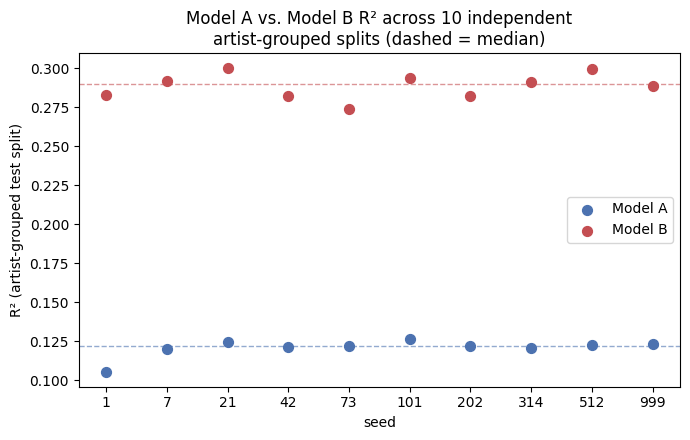

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
seed_labels = [str(s) for s in sweep["seed"]]
x = np.arange(len(seed_labels))
ax.scatter(x, sweep["model_a_r2"], label="Model A", color="#4C72B0", s=50)
ax.scatter(x, sweep["model_b_r2"], label="Model B", color="#C44E52", s=50)
ax.axhline(sweep["model_a_r2"].median(), color="#4C72B0", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(sweep["model_b_r2"].median(), color="#C44E52", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(seed_labels)
ax.set_xlabel("seed")
ax.set_ylabel("R² (artist-grouped test split)")
ax.set_title("Model A vs. Model B R² across 10 independent\nartist-grouped splits (dashed = median)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_model_comparison_grouped_split.png", dpi=150)
plt.show()

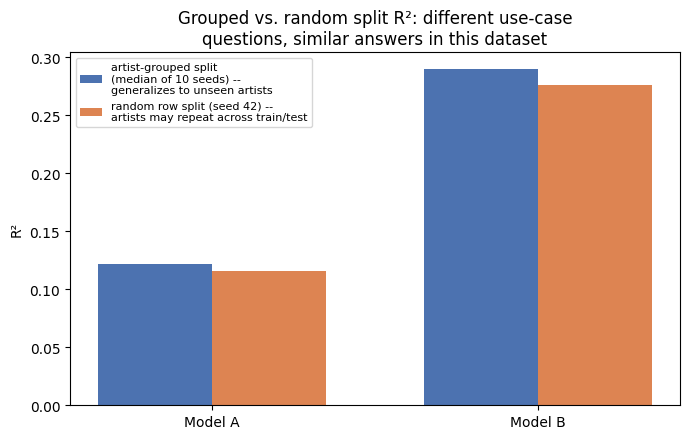

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ["Model A", "Model B"]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [sweep["model_a_r2"].median(), sweep["model_b_r2"].median()],
       width, label="artist-grouped split\n(median of 10 seeds) --\ngeneralizes to unseen artists", color="#4C72B0")
ax.bar(x + width/2, [model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]],
       width, label="random row split (seed 42) --\nartists may repeat across train/test", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("R²")
ax.set_title("Grouped vs. random split R²: different use-case\nquestions, similar answers in this dataset")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_grouped_vs_random_split.png", dpi=150)
plt.show()

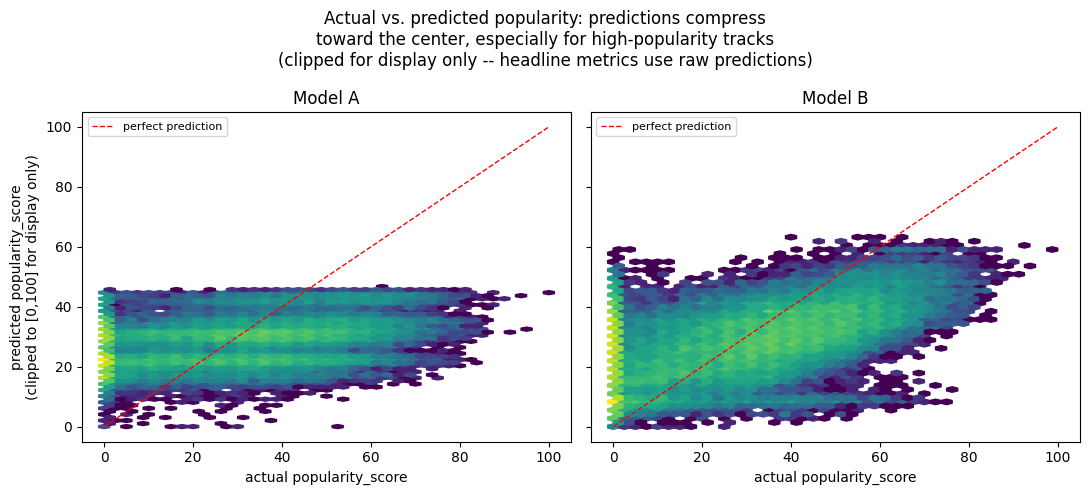

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, res, name in zip(axes, [model_a_g, model_b_g], ["Model A", "Model B"]):
    y_true = res["y_test"]
    y_pred_clipped = M.clip_predictions(res["y_pred"])
    ax.hexbin(y_true, y_pred_clipped, gridsize=40, cmap="viridis", mincnt=1, bins="log")
    ax.plot([0, 100], [0, 100], color="red", linewidth=1, linestyle="--", label="perfect prediction")
    ax.set_xlabel("actual popularity_score")
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("predicted popularity_score\n(clipped to [0,100] for display only)")
fig.suptitle("Actual vs. predicted popularity: predictions compress\ntoward the center, especially for high-popularity tracks\n(clipped for display only -- headline metrics use raw predictions)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_actual_vs_predicted.png", dpi=150)
plt.show()

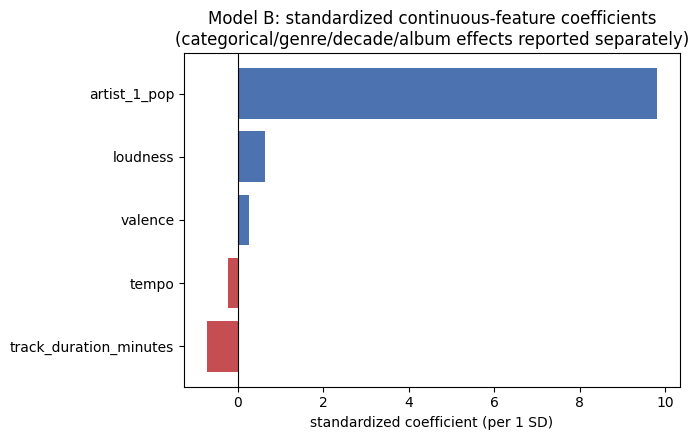

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_coefs = continuous_coefs.sort_values()
colors_c = ["#C44E52" if v < 0 else "#4C72B0" for v in plot_coefs.values]
ax.barh(plot_coefs.index, plot_coefs.values, color=colors_c)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient (per 1 SD)")
ax.set_title("Model B: standardized continuous-feature coefficients\n(categorical/genre/decade/album effects reported separately)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_standardized_coefficients.png", dpi=150)
plt.show()

## 14. Limitations

- **Observational data; no causal claims.** Every association reported here
  is descriptive, evaluated on held-out data.
- **`artist_1` remains an imperfect canonical artist identifier** even
  after the grouping-key correction (§4) — it may still contain
  concatenated collaborator names for otherwise-normal-looking entries.
  This fix addresses the one concrete, identifiable failure mode found in
  this extract (a small set of placeholder labels), not every theoretically
  possible one.
- **Target-range compression (§10)** is a central, not incidental, limit of
  this linear specification on this feature set and dataset — it does not
  identify extreme popularity well, and this analysis does not attempt a
  nonlinear fix (out of scope for this phase).
- **Genre availability is not random** (Phase 2 §15).
- **Release decade is entangled with recency/survivorship/catalog
  composition**, not a pure content attribute.
- **Sampling frame and collection time remain unverified** (Phase 2).
- Grouped-split R² varies modestly across seeds (§6) — attributed to test-
  fold composition, not model instability, given the now-small maximum
  group size (§4) and identical specification across seeds.
- Model performance is modest (R² ≈0.11–0.13 for Model A,
  ≈0.27–0.30 for Model B across grouped seeds) — reported plainly.

## 15. Conclusions

- Model A (content/context only) explains a modest, consistent share of
  popularity variation across every evaluation design tried (R² ≈0.11–0.13).
- Model A's predictions compress strongly toward the middle of the
  popularity distribution and substantially underpredict genuinely
  high-popularity tracks — a central limitation of this feature set and
  linear specification on this dataset, not a minor footnote.
- Model B (+ `artist_1_pop`) materially and consistently outperforms Model
  A (R² ≈0.27–0.30 across 10 independent artist-grouped splits, and
  similarly under a random row split) — its value is not an artifact of a
  single convenient split, and (with the grouping-key fix in §4) is not
  primarily explained by inappropriate train/test information flow either.
- The random and artist-grouped splits answer different practical
  questions in principle (already-known vs. entirely unseen artists); in
  this dataset, with a corrected grouping key, they point to a similar
  conclusion rather than a sharply different one.
- `artist_1_pop`'s coefficient and predictive value are reported
  descriptively, not causally — it remains conceptually close to the
  outcome, and its usefulness in a real deployment would depend on whether
  new tracks come from already-represented or genuinely new artists.
- Metadata limitations — genre missingness (Phase 2) and placeholder artist
  identities (this phase) — materially affect interpretation and were
  investigated directly rather than left as unexamined caveats.
- No claim is made that content/context characteristics, or artist
  popularity, *cause* track popularity — only that they are associated with
  it, to the degree, and with the caveats, quantified above.